In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical
import numpy as np
import pandas as pd

train_df = pd.read_csv("sign_mnist_train.csv")
test_df = pd.read_csv("sign_mnist_test.csv")

train_labels = train_df.iloc[:, 0].values
train_images = train_df.iloc[:, 1:].values
test_labels = test_df.iloc[:, 0].values
test_images = test_df.iloc[:, 1:].values

train_images = train_images.reshape(-1, 28, 28, 1) / 255.0
test_images = test_images.reshape(-1, 28, 28, 1) / 255.0

train_labels = to_categorical(train_labels, num_classes=25) 
test_labels = to_categorical(test_labels, num_classes=25)


In [2]:
model = Sequential()

model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(25, activation='softmax'))  
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()


c:\Users\tanin\OneDrive\Desktop\Data mining\myenv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 226,969 (886.60 KB)

 Trainable params: 226,969 (886.60 KB)

 Non-trainable params: 0 (0.00 B)

In [3]:
# Model Training
history = model.fit(train_images, train_labels, epochs=10, batch_size=32, validation_data=(test_images, test_labels))


Epoch 1/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.4898 - loss: 1.7542 - val_accuracy: 0.8537 - val_loss: 0.4727
Epoch 2/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.9834 - loss: 0.0780 - val_accuracy: 0.9050 - val_loss: 0.3695
Epoch 3/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9996 - loss: 0.0076 - val_accuracy: 0.9049 - val_loss: 0.3774
Epoch 4/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9996 - loss: 0.0054 - val_accuracy: 0.8846 - val_loss: 0.4555
Epoch 5/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9954 - loss: 0.0216 - val_accuracy: 0.9223 - val_loss: 0.3837
Epoch 6/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 1.0000 - loss: 3.4637e-04 - val_accuracy: 0.9286 - val_loss: 0.3828
Epoch 7/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 1.0000 - loss: 2.1860e-04 - val_accuracy: 0.9289 - val_loss: 0.3733
Epoch 8/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 1.0000 - loss: 1.304

In [4]:
# Model Evaluation
test_loss, test_accuracy = model.evaluate(test_images, test_labels)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9121 - loss: 0.4567
Test Accuracy: 91.38%


In [5]:
# Predictions
predictions = model.predict(test_images)

predicted_labels = np.argmax(predictions, axis=1)
print(predicted_labels)


225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
[ 6  5 10 ...  2  4  2]


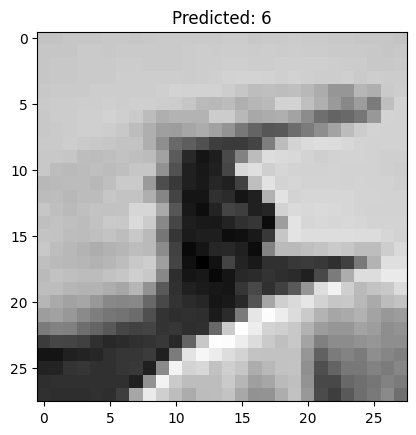

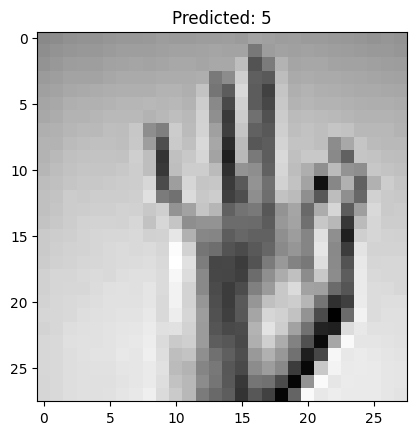

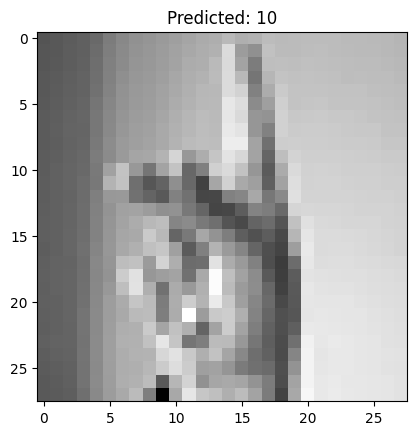

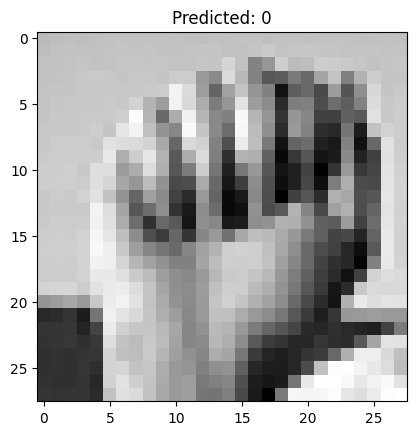

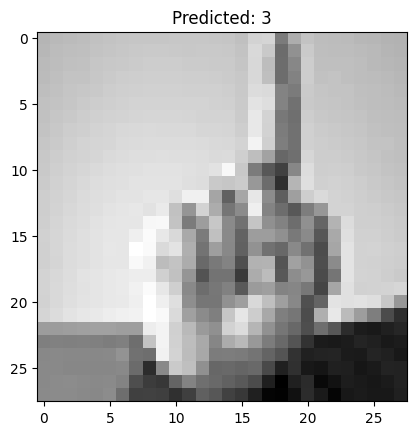

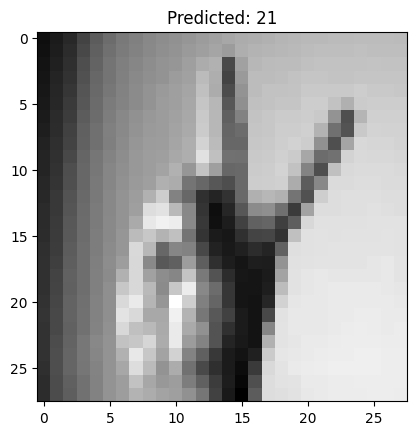

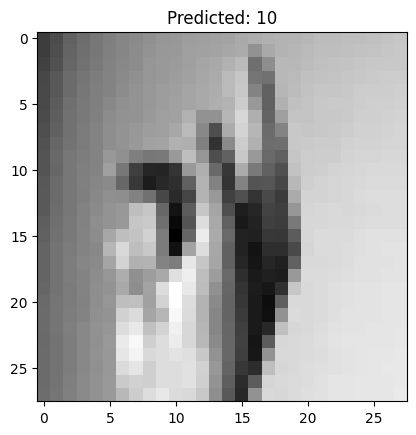

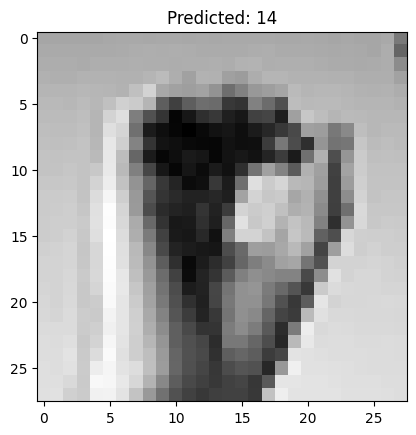

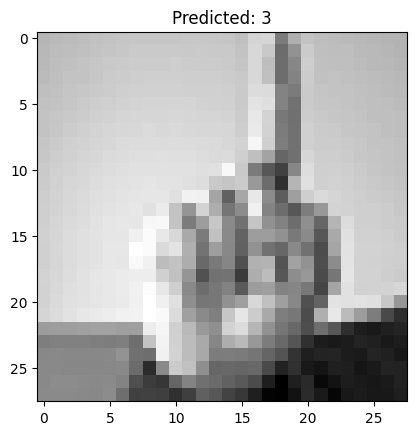

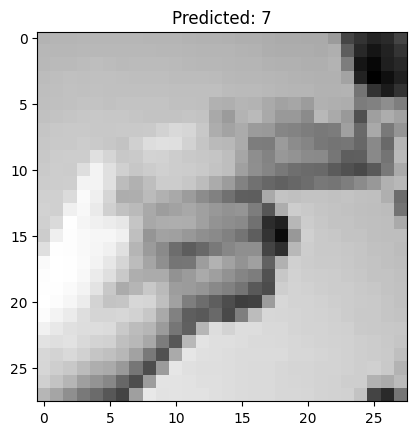

In [6]:
import matplotlib.pyplot as plt

# Visualize images and prediction
for i in range(10):
    plt.imshow(test_images[i].reshape(28, 28), cmap='gray')
    plt.title(f"Predicted: {predicted_labels[i]}")
    plt.show()


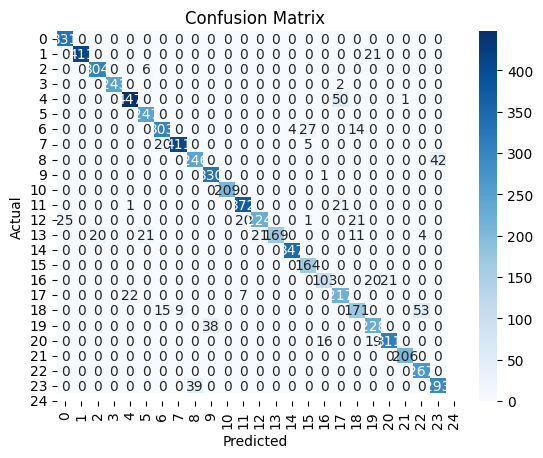

In [7]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

cm = confusion_matrix(np.argmax(test_labels, axis=1), predicted_labels)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=range(25), yticklabels=range(25))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [8]:
model.save('mnist_mod_test.keras')
print("Model saved.")

Model saved.
